In [1]:
%load_ext autoreload
%autoreload 2
%cd ../..

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/strokerehab_2025/vlms4rehab


In [2]:
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "postprocess/primitives")
import plot_from_log as P  # robust JSONL record iterator

PRIMITIVES = ["idle", "reach", "transport", "reposition", "stabilize"]
IDX = {p: i for i, p in enumerate(PRIMITIVES)}
LOG = "logs_qwen2_5_sig_gen_final/20251104_095353_samples_strokerehab_primitives_3.jsonl"

In [17]:
# Canonical parser from the task code (data/utils_strokerehab.py). The log's `target` and
# `filtered_resps` are written by resps_to_string(), which appends a duplicated final
# primitive as an end-time sentinel; string_to_resps() drops it and returns (prims, times)
# with len(times) == len(prims) + 1, i.e. segment i spans [times[i], times[i+1]).
from data.utils_strokerehab import string_to_resps


def parse_segments(s):
    """Canonical parse -> (prims, times); segment i spans [times[i], times[i+1])."""
    if isinstance(s, list):
        s = ";".join(str(x) for x in s)
    prims, times = string_to_resps(s, drop_duplicated=True)
    return [p.strip().lower() for p in prims], list(times)


def gt_label_at(gt_prims, gt_times, t):
    """Ground-truth primitive active at time t.

    - pre-onset (t before the first labelled segment) -> 'idle' (resting state)
    - at/past the last segment boundary -> the last segment's primitive (clamp)
    - otherwise: the primitive of the segment covering t
    """
    if t >= gt_times[-1] - 1e-9:
        return gt_prims[-1]
    i = int(np.searchsorted(gt_times, t, side="right")) - 1
    return "idle" if i < 0 else gt_prims[i]


def build_confusion(log_path):
    """Frame-level confusion matrix, rows = predicted, cols = ground truth.

    One unit per prediction frame in `filtered_resps` (the ~0.53 s signal-generator grid,
    every 32nd native frame at 60 fps). For each frame:
      - it is kept iff its START falls within the GT span (start < gt_end); frames that
        start past the last GT segment are dropped (the ~28 tail frames -> total 9036), and
      - it is labelled by the GT primitive at the frame's MIDPOINT, (start + end) / 2, so it
        is scored by what the ground truth was doing during the bulk of the interval.
    """
    cm = np.zeros((len(PRIMITIVES), len(PRIMITIVES)), dtype=int)
    n_records = 0
    for rec in P.iter_json_records_from_log(log_path):
        gt_prims, gt_times = parse_segments(rec.get("target", ""))
        pred_prims, pred_times = parse_segments(rec.get("filtered_resps", ""))
        n_records += 1
        duration = rec["duration_s"]
        gt_end = gt_times[-1]
        for i, p in enumerate(pred_prims):
            if pred_times[i] >= gt_end - 1e-9:  # tail-drop on the frame's START time
                continue
            t_next = pred_times[i + 1] if i + 1 < len(pred_times) else duration
            t_mid = (pred_times[i] + t_next) / 2.0  # label at the frame midpoint
            g = gt_label_at(gt_prims, gt_times, t_mid)
            cm[IDX[p], IDX[g]] += 1
    return cm, n_records


cm, n_records = build_confusion(LOG)
print(f"{n_records} videos, {cm.sum()} frames")
print("GT class totals:", dict(zip(PRIMITIVES, cm.sum(0).tolist())))
print("Recall (%):", {p: round(cm[i, i] / cm[:, i].sum() * 100, 1) for i, p in enumerate(PRIMITIVES)})

90 videos, 9036 frames
GT class totals: {'idle': 1571, 'reach': 1671, 'transport': 3822, 'reposition': 1019, 'stabilize': 953}
Recall (%): {'idle': 61.3, 'reach': 23.6, 'transport': 82.2, 'reposition': 17.7, 'stabilize': 4.8}


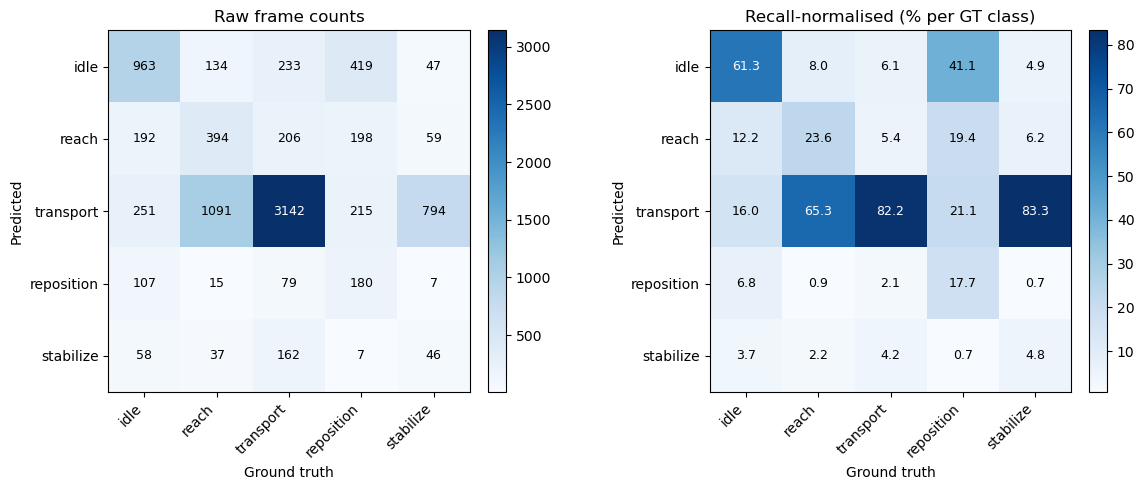

In [18]:
# column-normalised (% per ground-truth class) -> diagonal is per-class recall
cm_recall = cm / cm.sum(axis=0, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
panels = [
    (axes[0], cm, "Raw frame counts", "{:d}"),
    (axes[1], cm_recall, "Recall-normalised (% per GT class)", "{:.1f}"),
]
for ax, mat, title, fmt in panels:
    im = ax.imshow(mat, cmap="Blues")
    thresh = mat.max() * 0.5
    for i in range(len(PRIMITIVES)):
        for j in range(len(PRIMITIVES)):
            ax.text(
                j,
                i,
                fmt.format(mat[i, j]),
                ha="center",
                va="center",
                fontsize=9,
                color="white" if mat[i, j] > thresh else "black",
            )
    ax.set_xticks(range(len(PRIMITIVES)))
    ax.set_xticklabels(PRIMITIVES, rotation=45, ha="right")
    ax.set_yticks(range(len(PRIMITIVES)))
    ax.set_yticklabels(PRIMITIVES)
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Predicted")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("primitive_confusion_matrix.pdf", bbox_inches="tight", dpi=300)
plt.show()